In [42]:
import pandas as pd
import numpy as np
import seaborn as sns  # Added import for seaborn

# Data visualization libraries
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_style('darkgrid')  # Set consistent plot style using seaborn's method
from datetime import datetime  # For date/time operations


import warnings
warnings.simplefilter('ignore')

In [43]:
uncleaned_data = pd.read_pickle('nifty_options_data_2019_2022_raw.bz2')

In [44]:
uncleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127605 entries, 0 to 127604
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           127605 non-null  datetime64[ns]
 1   Symbol         127605 non-null  object        
 2   Expiry         127605 non-null  object        
 3   Option Type    127605 non-null  object        
 4   Strike Price   127605 non-null  int64         
 5   Close          127605 non-null  float64       
 6   Last           127605 non-null  float64       
 7   Open Interest  127601 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 7.8+ MB


In [45]:
uncleaned_data.isna().sum()

,0
Date,0
Symbol,0
Expiry,0
Option Type,0
Strike Price,0
Close,0
Last,0
Open Interest,4


In [46]:
uncleaned_data.dropna(axis=0, how='any', inplace=True)

uncleaned_data.isna().sum()

,0
Date,0
Symbol,0
Expiry,0
Option Type,0
Strike Price,0
Close,0
Last,0
Open Interest,0


In [47]:
print(uncleaned_data.duplicated().value_counts())

print("Proportion of duplicate values is {} %".format(
      round((uncleaned_data.duplicated().value_counts()[1]/uncleaned_data.shape[0])*100, 2)))

False    127529
True         72
Name: count, dtype: int64
Proportion of duplicate values is 0.06 %


In [48]:
uncleaned_data = uncleaned_data.drop_duplicates()

print(uncleaned_data.duplicated().value_counts())

False    127529
Name: count, dtype: int64


In [49]:

uncleaned_data.Expiry = pd.to_datetime(uncleaned_data.Expiry)

days_to_expiry = (uncleaned_data['Expiry'] - uncleaned_data['Date']).dt.days

uncleaned_data.loc[days_to_expiry < 0]

,Date,Symbol,Expiry,Option Type,Strike Price,Close,Last,Open Interest
127604,2022-05-27,NIFTY,2022-05-26,PE,18150,2070.65,2070.65,1700.0


In [50]:
uncleaned_data.drop(127604)

,Date,Symbol,Expiry,Option Type,Strike Price,Close,Last,Open Interest
0,2019-01-01,NIFTY,2019-01-31,CE,8900,1455.95,0.00,0.0
1,2019-01-01,NIFTY,2019-01-31,CE,8950,1412.75,0.00,0.0
2,2019-01-01,NIFTY,2019-01-31,CE,9000,1942.65,1951.00,1096950.0
3,2019-01-01,NIFTY,2019-01-31,CE,9050,1327.70,0.00,0.0
4,2019-01-01,NIFTY,2019-01-31,CE,9100,1710.80,1710.80,6600.0
...,...,...,...,...,...,...,...,...
127527,2022-05-26,NIFTY,2022-05-26,PE,17950,1939.80,1939.80,1550.0
127528,2022-05-26,NIFTY,2022-05-26,PE,18000,1840.95,1833.90,91400.0
127529,2022-05-26,NIFTY,2022-05-26,PE,18050,1905.25,1885.00,1500.0
127530,2022-05-26,NIFTY,2022-05-26,PE,18100,1956.20,1934.10,50300.0


In [51]:
df = pd.read_csv("nifty_spot.csv").iloc[:41]
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-01-02,10868.849609,10895.349609,10735.049805,10792.500000,10792.500000,309700.0
1,2019-01-03,10796.799805,10814.049805,10661.250000,10672.250000,10672.250000,286200.0
2,2019-01-04,10699.700195,10741.049805,10628.650391,10727.349609,10727.349609,296600.0
3,2019-01-07,10804.849609,10835.950195,10750.150391,10771.799805,10771.799805,269400.0
4,2019-01-08,10786.250000,10818.450195,10733.250000,10802.150391,10802.150391,277700.0


In [52]:
df['year'] = pd.to_datetime(df['Date']).dt.strftime('%Y')
df['month'] = pd.to_datetime(df['Date']).dt.strftime('%m')

# Convert the date column from string to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [53]:
df["SMA_5"] = df["Close"].rolling(5).mean()

# Last day SMA line is below close price line and next day SMA line is above close line
bullish_condition_crossover = (df["Close"].shift(1) < df["SMA_5"].shift(1)) & (df["Close"] > df["SMA_5"])

# Make a new column in a dataframe and set it as 1 if there is bullish crossover else 0
df['Signal'] = np.where(bullish_condition_crossover,1,0)

# Last day SMA line is above the close price line and next day SMA line is below the close line
bearish_condition_crossover = (df["Close"].shift(1) > df["SMA_5"].shift(1)) & (df["Close"] < df["SMA_5"])

# If there is bearish crossover make signal col -1  else let it be unchanged
df['Signal'] = np.where(bearish_condition_crossover,-1,df['Signal'])

In [54]:
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume,year,month,SMA_5,Signal
0,2019-01-02,10868.849609,10895.349609,10735.049805,10792.500000,10792.500000,309700.0,2019,01,NaN,0
1,2019-01-03,10796.799805,10814.049805,10661.250000,10672.250000,10672.250000,286200.0,2019,01,NaN,0
2,2019-01-04,10699.700195,10741.049805,10628.650391,10727.349609,10727.349609,296600.0,2019,01,NaN,0
3,2019-01-07,10804.849609,10835.950195,10750.150391,10771.799805,10771.799805,269400.0,2019,01,NaN,0
4,2019-01-08,10786.250000,10818.450195,10733.250000,10802.150391,10802.150391,277700.0,2019,01,10753.209961,0


In [55]:
new_option_df = pd.read_pickle('nifty_options_data_2019_2022.bz2')

# Keep the contracts only with sufficient liquidity
new_option_df = new_option_df[new_option_df['Open Interest']>500]

# Set default index
new_option_df = new_option_df.reset_index()

# Show the first 10 columns and the first two months of data
new_option_df = new_option_df.iloc[:6256,:10]

new_option_df.head(5)

,Date,Symbol,Expiry,Option Type,Strike Price,Open,High,Low,Close,Last
0,2019-01-01,NIFTY,31-01-2019,CE,9000,1904.2,1951.1,1838.35,1942.65,1951.00
1,2019-01-01,NIFTY,31-01-2019,CE,9100,0.0,0.0,0.00,1710.80,1710.80
2,2019-01-01,NIFTY,31-01-2019,CE,9200,0.0,0.0,0.00,1712.70,1712.70
3,2019-01-01,NIFTY,31-01-2019,CE,9300,0.0,0.0,0.00,1608.10,1608.10
4,2019-01-01,NIFTY,31-01-2019,CE,9400,1465.8,1465.8,1453.45,1453.45,1453.45


In [56]:
# Define a dictionary which will be the new option dataframe
new_option_daily = {}

# Segregate all the data into groups based on the current date
for group_index1, sliced_df1 in new_option_df.groupby(["Date"]):
    temp2 = {}

    # Group smaller groups based on option type PE/CE
    for group_index2, sliced_df2 in sliced_df1.groupby(["Option Type"]):
        strikes = []
        temp3 = {}

        # Store premium corrresponding to each strike
        for group_index3, sliced_df3 in sliced_df2.groupby(["Strike Price"]):
            temp3[group_index3[0]] = sliced_df3['Close'].values[0]
        temp2[group_index2[0]] = temp3

    new_option_daily[group_index1[0].date()] = temp2

In [57]:
new_option_daily

{datetime.date(2019, 1, 1): {'CE': {9000: np.float64(1942.65),
   9100: np.float64(1710.8),
   9200: np.float64(1712.7),
   9300: np.float64(1608.1),
   9400: np.float64(1453.45),
   9500: np.float64(1450.0),
   9600: np.float64(1353.5),
   9700: np.float64(1208.05),
   9750: np.float64(1050.0),
   9800: np.float64(1080.45),
   9900: np.float64(983.25),
   10000: np.float64(962.95),
   10100: np.float64(821.3),
   10200: np.float64(771.7),
   10300: np.float64(684.2),
   10400: np.float64(593.45),
   10450: np.float64(530.0),
   10500: np.float64(506.7),
   10550: np.float64(453.35),
   10600: np.float64(427.05),
   10650: np.float64(385.6),
   10700: np.float64(346.1),
   10750: np.float64(311.7),
   10800: np.float64(276.7),
   10850: np.float64(243.15),
   10900: np.float64(211.25),
   10950: np.float64(183.15),
   11000: np.float64(154.15),
   11050: np.float64(130.4),
   11100: np.float64(106.95),
   11150: np.float64(87.75),
   11200: np.float64(69.8),
   11250: np.float64(55.5),

In [58]:
# Date given in string format
date_str = '02-20-2019'

# Convert string to date object
date = datetime.strptime(date_str, '%m-%d-%Y').date()

# Access from option dataframe
new_option_daily[date]['PE'][10750]

np.float64(88.4)

In [65]:
new_trades = []
last_date = -1

spread = 200

for grouper_index, sliced_df in df.groupby(["year", "month"]):

  cnt = 0
  trade_df = sliced_df
  last_date = trade_df.iloc[-1]['Date'].date()
  pos = 0
  new_trade = {}
  atm_strike = -1
  otm_strike = -1
  itm_strike = -1
  lot_size = 1

  for index, row in trade_df.iterrows():

    date = trade_df.iloc[cnt]['Date'].date()
    spot_price = trade_df.iloc[cnt,4]
    print(date, pos)

    if pos == 0:

      if(trade_df.iloc[cnt]['Signal']==1 and date != last_date):

        pos=1
        print("Entry date in long position is ", date)

        available_strikes = [strike for strike in new_option_daily[date]['CE'].keys()]

        difference_1 = lambda input_list : abs(input_list - spot_price)
        atm_strike = min(available_strikes,key=difference_1)

        difference_2 = lambda input_list : abs(input_list - (spot_price+spread))
        otm_strike = min(available_strikes,key=difference_2)

        new_trade['entry_day'] = date
        new_trade['entry_signal'] = "Long"
        new_trade['spot_price_at_entry'] = spot_price
        new_trade['long_option_strike'] = atm_strike
        new_trade['short_option_strike'] = otm_strike
        new_trade['entry_long_option_premium'] = new_option_daily[date]['CE'][atm_strike]
        new_trade['entry_short_option_premium'] = new_option_daily[date]['CE'][otm_strike]
        new_trade['Entry_Debit'] = lot_size*(new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

      if(trade_df.iloc[cnt]['Signal']==-1 and date != last_date):

        pos = -1
        print("Entry date in short position is ",date)

        available_strikes = [strike for strike in new_option_daily[date]['PE'].keys()]

        difference_1 = lambda input_list : abs(input_list - (spot_price+spread))
        itm_strike = min(available_strikes,key=difference_1)

        difference_2 = lambda input_list : abs(input_list - spot_price)
        atm_strike = min(available_strikes,key=difference_2)

        new_trade['entry_day'] = date
        new_trade['entry_signal'] = "Short"
        new_trade['spot_price_at_entry'] = spot_price
        new_trade['long_option_strike'] = itm_strike
        new_trade['short_option_strike'] = atm_strike
        new_trade['entry_long_option_premium'] = new_option_daily[date]['PE'][itm_strike]
        new_trade['entry_short_option_premium'] = new_option_daily[date]['PE'][atm_strike]
        new_trade['Entry_Debit'] = lot_size*(new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

    else:

      if(pos == 1):

        curr_val = lot_size*(new_option_daily[date]['CE'][atm_strike] - new_option_daily[date]['CE'][otm_strike])

        if curr_val < 0.95*(1*new_trade['Entry_Debit']):

          pos = 0
          print("Exit date due to stoploss ",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['CE'][otm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          new_trade = {}

        elif curr_val > 1.1*(1*new_trade['Entry_Debit']):

          pos = 0
          print("Exit date due to take-profit target hit",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['CE'][otm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          new_trade = {}

        elif (trade_df.iloc[cnt]['Signal']==-1):

          pos = 0
          print("Exit date is for signal",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['CE'][otm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          new_trade = {}

          pos = -1
          print("Entry date in short position is ",date)

          available_strikes = [strike for strike in new_option_daily[date]['PE'].keys()]

          difference_1 = lambda input_list : abs(input_list - (spot_price+spread))
          itm_strike = min(available_strikes,key=difference_1)

          difference_2 = lambda input_list : abs(input_list - spot_price)
          atm_strike = min(available_strikes,key=difference_2)

          new_trade['entry_day'] = date
          new_trade['entry_signal'] = "Short"
          new_trade['spot_price_at_entry'] = spot_price
          new_trade['long_option_strike'] = itm_strike
          new_trade['short_option_strike'] = atm_strike
          new_trade['entry_long_option_premium'] = new_option_daily[date]['PE'][itm_strike]
          new_trade['entry_short_option_premium'] = new_option_daily[date]['PE'][atm_strike]
          new_trade['Entry_Debit'] = lot_size*(new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

        elif (date == last_date):

          print("exit date is for expiry",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['CE'][atm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['CE'][otm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          pos = 0
          new_trade = {}

      elif(pos == -1):

        curr_val = lot_size*(new_option_daily[date]['PE'][itm_strike] - new_option_daily[date]['PE'][atm_strike])

        if curr_val < 0.95*(1*new_trade['Entry_Debit']):

          pos = 0
          print("exit date due to stoploss",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['PE'][itm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['PE'][atm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          new_trade = {}

        elif curr_val > 1.1*(1*new_trade['Entry_Debit']):

          pos = 0
          print("exit date due to take-profit target hit",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['PE'][itm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['PE'][atm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          new_trade = {}

        elif(trade_df.iloc[cnt]['Signal']==1):

          pos = 0
          print("exit date is for expiry",date)

          new_trade['exit_day'] = date
          new_trade['spot_price_at_exit'] = spot_price
          new_trade['exit_long_option_premium'] = new_option_daily[date]['PE'][itm_strike]
          new_trade['exit_short_option_premium'] = new_option_daily[date]['PE'][atm_strike]
          new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
          new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

          new_trades.append(new_trade)
          new_trade = {}

          pos=1
          print("Entry date in long positon is ",date)

          available_strikes = [strike for strike in new_option_daily[date]['CE'].keys()]

          difference_1 = lambda input_list : abs(input_list - spot_price)
          atm_strike = min(available_strikes,key=difference_1)

          difference_2 = lambda input_list : abs(input_list - (spot_price+spread))
          otm_strike = min(available_strikes,key=difference_2)

          new_trade['entry_day'] = date
          new_trade['entry_signal'] = "Long"
          new_trade['spot_price_at_entry'] = spot_price
          new_trade['long_option_strike'] = atm_strike
          new_trade['short_option_strike'] = otm_strike
          new_trade['entry_long_option_premium'] = new_option_daily[date]['CE'][atm_strike]
          new_trade['entry_short_option_premium'] = new_option_daily[date]['CE'][otm_strike]
          new_trade['Entry_Debit'] = lot_size*(new_trade['entry_long_option_premium']-new_trade['entry_short_option_premium'])

        elif (date == last_date):
            print("exit date is for expiry",date)
            new_trade['exit_day'] = date
            new_trade['spot_price_at_exit'] = spot_price
            new_trade['exit_long_option_premium'] = new_option_daily[date]['PE'][itm_strike]
            new_trade['exit_short_option_premium'] = new_option_daily[date]['PE'][atm_strike]
            new_trade['Exit_Credit'] = lot_size*(new_trade['exit_long_option_premium'] - new_trade['exit_short_option_premium'])
            new_trade['Profit'] = - new_trade['Entry_Debit'] + new_trade['Exit_Credit']

            new_trades.append(new_trade)
            pos = 0
            new_trade = {}

    cnt = cnt + 1

new_tradebook = pd.DataFrame(data=new_trades)
new_tradebook

KeyError: 'year'

In [66]:
print(df.columns)

Index(['win_ratio', 'loss_ratio', 'payoff_ratio', 'trade_expectancy'], dtype='object')


In [67]:

total_wins = len(new_tradebook[new_tradebook["Profit"] > 0])

total_losses = len(new_tradebook[new_tradebook["Profit"] < 0])

total_trades = len(new_tradebook)

win_ratio = round(total_wins/total_trades,2)

loss_ratio = round(total_losses / total_trades,2)

total_win_amount = new_tradebook[new_tradebook["Profit"] > 0]["Profit"].sum()

average_profit_in_profitable_trade = total_win_amount / total_wins

total_loss_amount = new_tradebook[new_tradebook["Profit"] < 0]["Profit"].sum()

average_loss_in_loss_trade = total_loss_amount / total_losses

payoff_ratio = average_profit_in_profitable_trade / average_loss_in_loss_trade

trade_expectancy = (win_ratio * average_profit_in_profitable_trade) / (loss_ratio * average_loss_in_loss_trade)

data = [[win_ratio,loss_ratio,payoff_ratio,trade_expectancy]]

df = pd.DataFrame(data,columns=['win_ratio','loss_ratio','payoff_ratio','trade_expectancy'], index = ['value'])


df

,win_ratio,loss_ratio,payoff_ratio,trade_expectancy
value,0.83,0.17,-3.640845,-17.775891


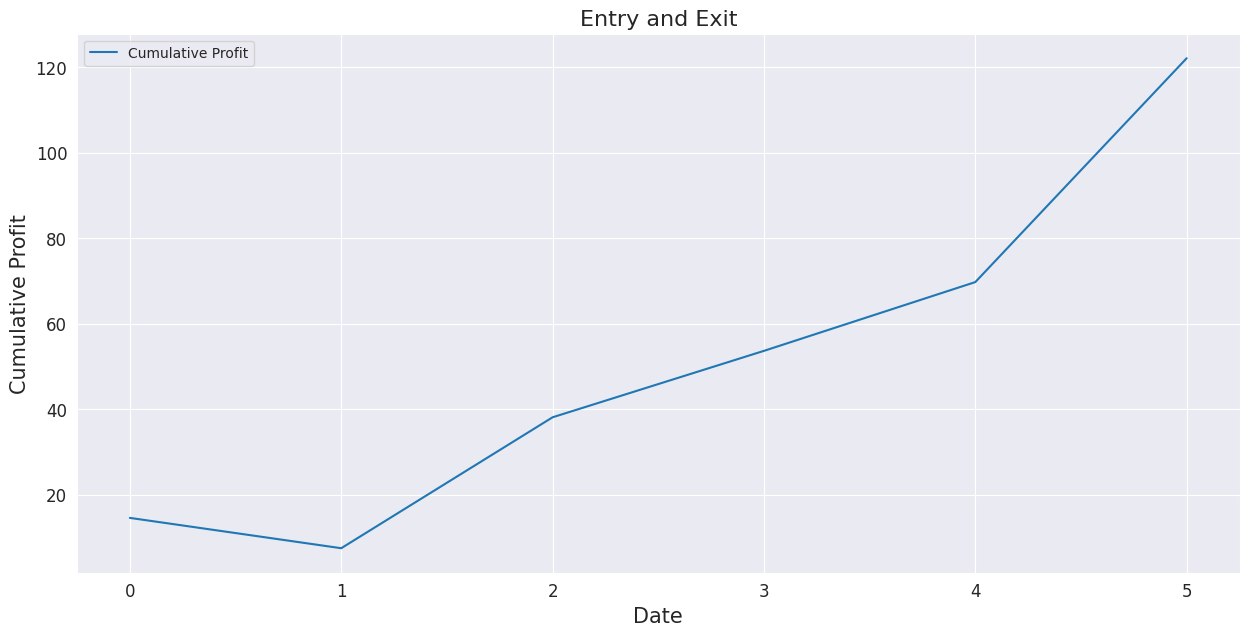

In [68]:
new_tradebook['Cumulative Profit'] = new_tradebook['Profit'].cumsum()


plt.figure(figsize=(15, 7))

profit = new_tradebook['Cumulative Profit'].plot()

profit.set_title('Entry and Exit', fontsize=16)
profit.set_ylabel('Cumulative Profit', fontsize=15)
profit.set_xlabel('Date', fontsize=15)

plt.legend(loc='best')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()